# CS4168 Data Mining Project  
## Spotify Tracks Dataset Analysis

This notebook performs:
- Exploratory Data Analysis (EDA)
- Clustering (K-Means & DBSCAN)
- Classification (Predicting Popularity Category)
- Regression (Predicting Popularity Score)

(Needs filling in and more detail)

To Activate .venv on Windows
-Set-ExecutionPolicy -Scope Process -ExecutionPolicy RemoteSigned   
-.venv\Scripts\Activate.ps1

In [22]:
# imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.impute import SimpleImputer

In [23]:
# Load de Data

df = pd.read_csv("tracks2026.csv")
df.head()

,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5xmO5SbFOiVrRGrMQhL4Jk,44.0,203337,False,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,5cF0dROlMOK5uNZtivgu50,83.0,208786,False,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,4OQ9XGe11ckizN2EBnNED2,49.0,262373,False,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,6Grw9OtoslF9JrDJ6pgsQG,0.0,191733,False,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,3fGpNiwYr981n72YY4DZvB,41.0,283706,False,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop


# 1. Exploratory Data Analysis

In [24]:
# Basic data inspect

df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          2000 non-null   str    
 1   popularity        1960 non-null   float64
 2   duration_ms       2000 non-null   int64  
 3   explicit          2000 non-null   bool   
 4   danceability      1960 non-null   float64
 5   energy            1960 non-null   float64
 6   key               2000 non-null   int64  
 7   loudness          1961 non-null   float64
 8   mode              2000 non-null   int64  
 9   speechiness       2000 non-null   float64
 10  acousticness      2000 non-null   float64
 11  instrumentalness  2000 non-null   float64
 12  liveness          2000 non-null   float64
 13  valence           2000 non-null   float64
 14  tempo             1960 non-null   float64
 15  time_signature    2000 non-null   int64  
 16  track_genre       2000 non-null   str    
dtypes: boo

track_id             0
popularity          40
duration_ms          0
explicit             0
danceability        40
energy              40
key                  0
loudness            39
mode                 0
speechiness          0
acousticness         0
instrumentalness     0
liveness             0
valence              0
tempo               40
time_signature       0
track_genre          0
dtype: int64

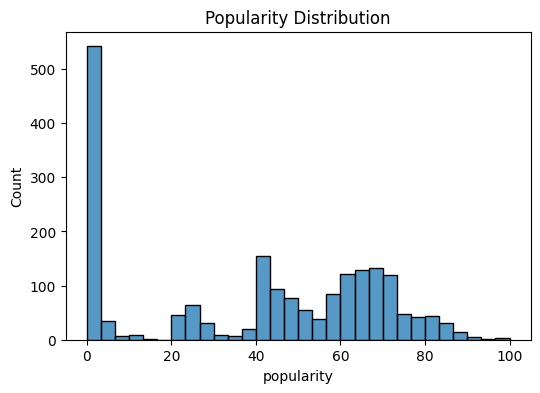

In [25]:
# Popularity distribution

plt.figure(figsize=(6,4))
sns.histplot(df["popularity"], bins=30)
plt.title("Popularity Distribution")
plt.show()

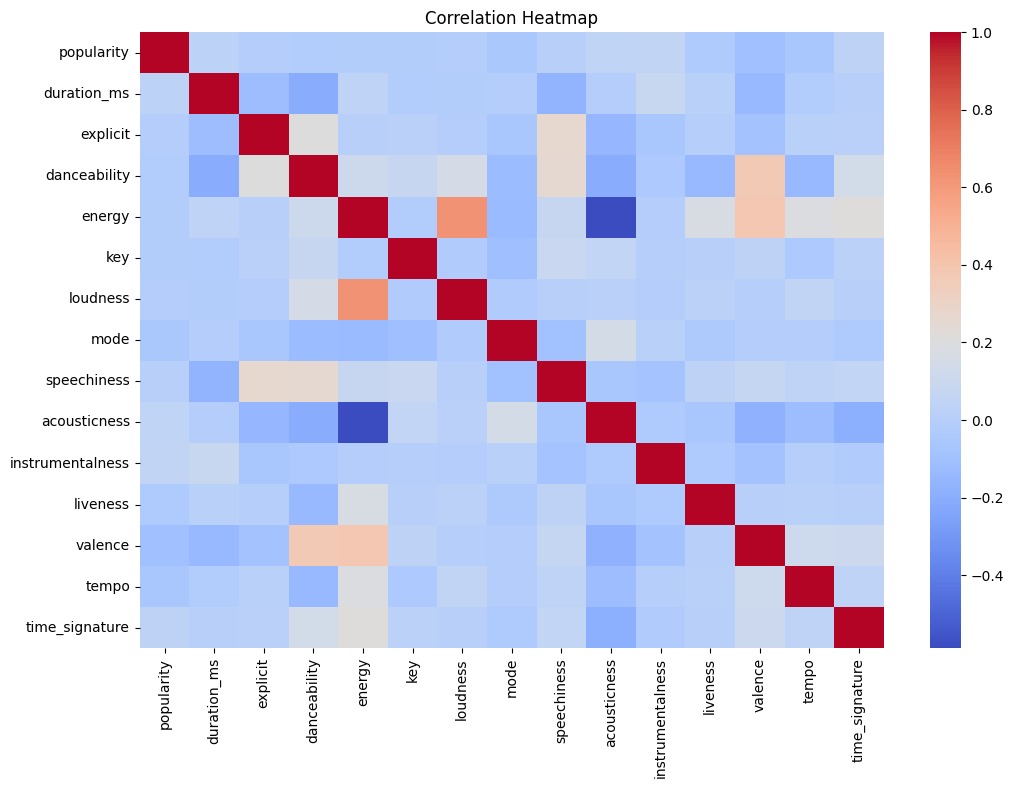

In [26]:
# Correlation Heatmap

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# 2. Clustering Analysis
Goes here

In [27]:
# Data prep for Clustering

X_cluster = df.drop(columns=["track_genre"])
X_cluster = X_cluster.select_dtypes(include=np.number)

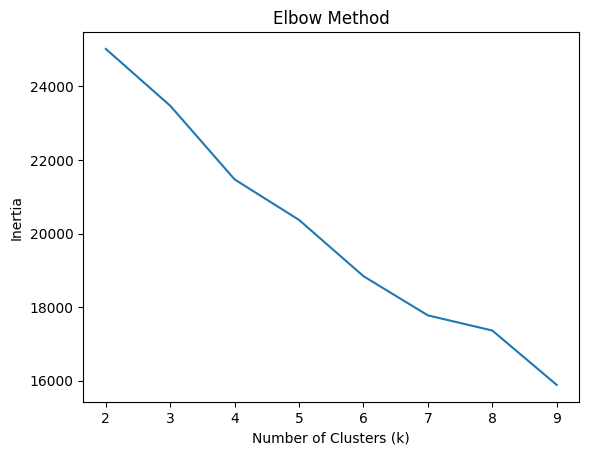

In [28]:
# Elbow method for K-Means

inertia = []

for k in range(2, 10):
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("kmeans", KMeans(n_clusters=k, random_state=42))
    ])
    
    pipe.fit(X_cluster)
    inertia.append(pipe.named_steps["kmeans"].inertia_)

plt.plot(range(2,10), inertia)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [29]:
# Fit Final K-Means (Eg - k=3)

kmeans_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=3, random_state=42))
])

kmeans_pipe.fit(X_cluster)

labels = kmeans_pipe.named_steps["kmeans"].labels_

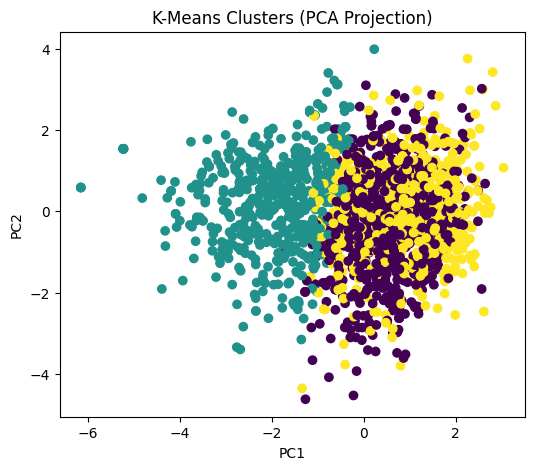

In [30]:
# Visualise Clusters (w/ PCA)

# Get preprocessing steps from the fitted pipeline
imputer = kmeans_pipe.named_steps["imputer"]
scaler = kmeans_pipe.named_steps["scaler"]

# Apply preprocessing
X_imputed = imputer.transform(X_cluster)
X_scaled = scaler.transform(X_imputed)

# Now PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.title("K-Means Clusters (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [32]:
# DBScan

dbscan_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("dbscan", DBSCAN(eps=1.5, min_samples=5))
])

dbscan_pipe.fit(X_cluster)

db_labels = dbscan_pipe.named_steps["dbscan"].labels_

print("Unique clusters:", np.unique(db_labels))

Unique clusters: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]


# 3. Classification: Predicting Popularity Category

Goes here